## Considere nuevamente la base de datos siguiente: FuelConsumptionCo2.xlsx

In [1]:
# Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Traer la base de datos a utlizar
df = pd.read_excel("FuelConsumptionCo2.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 945 non-null    int64  
 1   MAKE                      945 non-null    object 
 2   MODEL                     945 non-null    object 
 3   VEHICLECLASS              945 non-null    object 
 4   ENGINESIZE                945 non-null    float64
 5   CYLINDERS                 945 non-null    int64  
 6   TRANSMISSION              945 non-null    object 
 7   FUELTYPE                  945 non-null    object 
 8   FUELCONSUMPTION_CITY      945 non-null    float64
 9   FUELCONSUMPTION_HWY       945 non-null    float64
 10  FUELCONSUMPTION_COMB      945 non-null    float64
 11  FUELCONSUMPTION_COMB_MPG  945 non-null    int64  
 12  CO2EMISSIONS              945 non-null    int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 96.1+ KB


## Elimine las columnas de tipo categórico de la base de datos y verifique que no existan datos nulos que deban ser eliminados de manera previa al análisis.

In [3]:
BD_num = df.select_dtypes(exclude=['object'])
BD_num

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,2.4,4,9.9,7.0,8.6,33,200
1,2022,3.5,6,12.6,9.4,11.2,25,263
2,2022,2.0,4,11.0,8.6,9.9,29,232
3,2022,2.0,4,11.3,9.1,10.3,27,242
4,2022,2.0,4,11.2,8.0,9.8,29,230
...,...,...,...,...,...,...,...,...
940,2022,2.0,4,10.7,7.7,9.4,30,219
941,2022,2.0,4,10.5,8.1,9.4,30,219
942,2022,2.0,4,11.0,8.7,9.9,29,232
943,2022,2.0,4,11.5,8.4,10.1,28,236


NO hay un valor nulo


<Axes: >

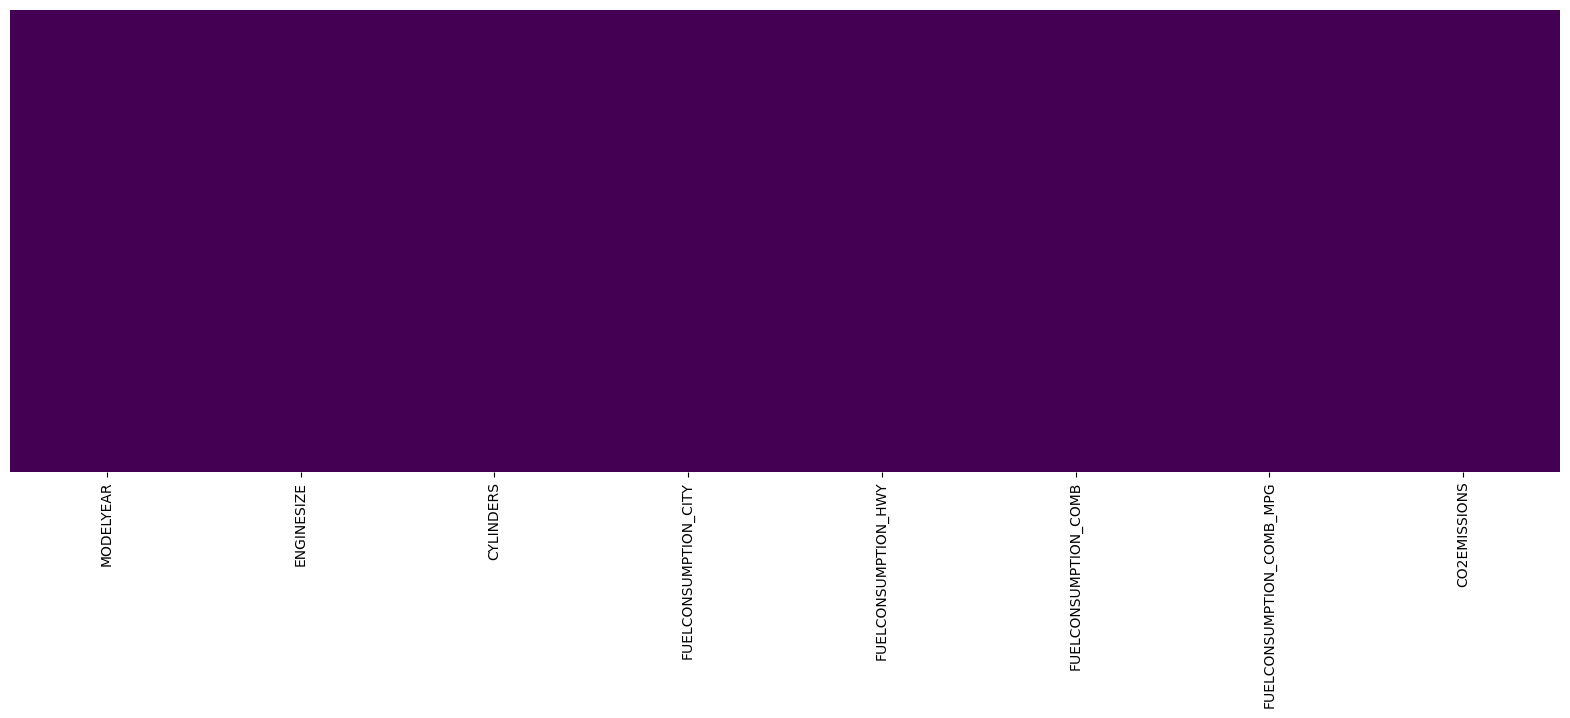

In [4]:
LocNull = 0
for x in BD_num:
    if x is True: 
        LocNull = 1
        break; 

if LocNull is True:
    print ("Hay un valor nulo")
else:
    print ("NO hay un valor nulo")

plt.figure(figsize = (20,6))
sns.heatmap(BD_num.isnull(), yticklabels=False, cbar=False, cmap="viridis" )

## Realice un análisis de regresión múltiple para pronosticar la variable “CO2 EMISSIONS” con las variables remanentes.

In [6]:
x = BD_num.drop("CO2EMISSIONS", axis=1) #X o datos independientes
y = BD_num["CO2EMISSIONS"] #Y o datos dependientes

In [7]:
#Division en grupos de entrenamiento (trining) y de prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state =1)

In [8]:
# Contruccion de un modelo de refresión lineal multiples
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

### Obtenga los indicadores de bondad de ajuste correspondientes (R cuadrada, Error medio absoluto, etc.).

In [10]:
# Cálculo de indicadores de la bondad de ajuste
from sklearn.metrics import r2_score
from sklearn import metrics

#Calcular las predicciones
y_pred = linreg.predict(X_test)
y_pred

# impresión de indicadores de bondad de ajuestes
print("Valor de R cuadrada: ",   r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ",   metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ",   np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Valor de R cuadrada:  0.9775327964689395
Error absoluto medio:  6.4183220979861995
Error cuadrático medio:  85.97881014782216
Raíz del error cuadrático medio:  9.272475944850013


### Utilice los coeficientes resultantes y pronostique la primera observación de la base de prueba. 

In [12]:
#Impresion de coeficientes de regresion
print ("Intercepto: ", linreg.intercept_)
print ("Coeficiente: ", linreg.coef_)

Intercepto:  124.05613100622443
Coeficiente:  [ 0.         -0.01515148  6.43036425 -1.32628678  0.52702525 14.53834062
 -1.88292508]


In [13]:
# Extraer la columna 0 de x para la muestra
Muestra1 = pd.DataFrame(x.iloc[0])
ex = Muestra1.transpose()

#Comparacion de coeficientes:
print("Valor esperado de Y: ", y[0])
print("Valor predicho de Y: ", linreg.predict(ex))

Valor esperado de Y:  200
Valor predicho de Y:  [203.19336392]


### ¿Coincide su resultado con aquel obtenido con la instrucción “predict”? Explique.

Los valores no son iguales, pero tienen una aproximación bastante cercana, además de que tiene una R**2 del 97.75 % PERO el valor cuadrático medio es de 85.9 por lo cual se revisaran otros métodos de predicción para reducir las medias de errores.

## Repita el ejercicio 3 pero aplicando un modelo de regresión Ridge mediante el valor de Alpha óptimo.

In [17]:
# Alpha = 0 (Equivalente a una Regresión lineal)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

#Definición un rango de prueba del -1 al 2 con pasos del 0.1
alpha_range = np.arange(0.1,2.1, 0.01)
alpha_range

# Estandarizacion de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Calcular el alpha mas optimo
ridgeregcv = RidgeCV(alphas=alpha_range, scoring= "neg_mean_squared_error")
ridgeregcv.fit(X_train_scaled, y_train)
ridgeregcv.alpha_

2.089999999999999

In [21]:
# Prediccion mediante el mejor valor de alpha
y_pred = ridgeregcv.predict(X_test_scaled)

# impresión de indicadores de bondad de ajuestes
print("Valor de R cuadrada: ",   r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ",   metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ",   np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Valor de R cuadrada:  0.977580069933218
Error absoluto medio:  6.408248943457973
Error cuadrático medio:  85.79790128639647
Raíz del error cuadrático medio:  9.26271565397516


In [22]:
# Examinacion de los coeficientes de la regresión Ridge
print ("Intercepto: ", ridgeregcv.intercept_)
print ("Coeficiente: ", ridgeregcv.coef_)

Intercepto:  261.5658093797277
Coeficiente:  [  0.           0.20952027  12.31573846  14.00650054  11.47031124
  14.69253927 -14.4188389 ]


### Utilice los coeficientes resultantes y pronostique la primera observación de la base de prueba.

In [27]:
# Extraer la columna 0 de x para la muestra
Muestra1 = pd.DataFrame(x.iloc[0])
ex = Muestra1.transpose()

#Comparacion de coeficientes:
print("Valor esperado de Y: ", y[0])
print("Valor predicho de Y: ", ridgeregcv.predict(ex))

Valor esperado de Y:  200
Valor predicho de Y:  [180.82229974]


### ¿Coincide su resultado con aquel obtenido con la instrucción “predict”? Explique.

Para Ridge la diferencia para la muestra inicial fue bastante elevada, esto debido a que, aunque tiene una R**2 del 97.75% la media del error cuadrático es bastante elevada, por lo cual en te caso en particular será necesario ver otros posibles métodos.

## Repita el ejercicio 3 pero aplicando un modelo de regresión Lasso mediante el valor de Alpha óptimo. 

In [35]:
# Prueba con Alpha = 0.001
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Estandarizacion de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Probar 100 alphas distintos para encontrar el mas optimo
lassoregcv = LassoCV (n_alphas = 1000, random_state=1)
lassoregcv.fit(X_train_scaled, y_train)
print("Alpha óptimo", lassoregcv.alpha_)


Alpha óptimo 0.18803835147691803


In [36]:
# Examinacion de los coeficientes de la regresión Lasso
print ("Intercepto: ", lassoregcv.intercept_)
print ("Coeficiente: ", lassoregcv.coef_)

Intercepto:  261.5658093797277
Coeficiente:  [  0.           0.          12.30624945  16.29792197  12.48562611
  11.60618232 -14.27831517]


In [37]:
# Prediccion mediante el mejor valor de alpha
y_pred = lassoregcv.predict(X_test_scaled)

# impresión de indicadores de bondad de ajuestes
print("Valor de R cuadrada: ",   r2_score(y_test, y_pred))
print("Error absoluto medio: ", metrics.mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio: ",   metrics.mean_squared_error(y_test, y_pred))
print("Raíz del error cuadrático medio: ",   np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Valor de R cuadrada:  0.9774677865961628
Error absoluto medio:  6.437598931567948
Error cuadrático medio:  86.22759373593007
Raíz del error cuadrático medio:  9.285881419441564


### Utilice los coeficientes resultantes y pronostique la primera observación de la base de prueba.

In [39]:
# Extraer la columna 0 de x para la muestra
Muestra1 = pd.DataFrame(x.iloc[0])
ex = Muestra1.transpose()

#Comparacion de coeficientes:
print("Valor esperado de Y: ", y[0])
print("Valor predicho de Y: ", lassoregcv.predict(ex))

Valor esperado de Y:  200
Valor predicho de Y:  [188.16838488]


### ¿Coincide su resultado con aquel obtenido con la instrucción “predict”? Explique.

En este caso calculando las dos opciones las alfas mas optimas se establecio que el año y tamaño de motor no afectarian a la prediccion, lo cual puede parecer contraintuitivo, pero incluso con esa prediccion contraintuitiva, tiene un R**2 del 97.74%, pero el error cuadratico medio sigue siendo vastante elevado. Pero la prediccion en este caso, almenos para este valor en particular esta mas alejado.

## ¿Cuál de los 3 modelos de regresión resultó ser el mejor? Explique a detalle.

## Regression Lineal
### Valor de R cuadrada:  0.9775327964689395
### Error absoluto medio:  6.4183220979861995
### Error cuadrático medio:  85.97881014782216
### Raíz del error cuadrático medio:  9.272475944850013

## Ridge
### Valor de R cuadrada:  0.977580069933218
### Error absoluto medio:  6.408248943457973
### Error cuadrático medio:  85.79790128639647
### Raíz del error cuadrático medio:  9.26271565397516

## Lasso
#### Valor de R cuadrada:  0.9774677865961628
#### Error absoluto medio:  6.437598931567948
#### Error cuadrático medio:  86.22759373593007
#### Raíz del error cuadrático medio:  9.285881419441564

### Las R**2 son similares entre todas variando con menos del 1%
### Con el error absoluto medio el ganador es Ridge, con una diferencia minúscula
### Para el Error cuadrático medio es mejor el del Ridge, también con una mínima diferencia.
### Para la raíz del Error cuadrático medio es Ridge, también con casi nada de diferencia.
Con esto dicho el “Mejor” en este caso sería con la predicción del método de Ridge, pero la diferencia es tan minúscula que las predicciones serían las mismas y esta seria elegida, aunque es contra-intuitivo, debido a la prueba de X en línea 0 fue la predicción con mayor diferencia, pero según cálculos este tiene mayor aproximación a lo largo de los análisis que el resto de predicciones